# Confidence Intervals

Confidence intervals are a calculated range or boundary around a parameter or a statistic that is supported
mathematically with a certain level of confidence.  For example, we estimate, with 95% confidence, that the
population proportion of teenagers who play video games is somewhere between 32.2% and 37.7%.

This is *__different__* than having a 95% probability that the true population proportion is within our confidence interval.

Essentially, if we were to repeat this process, 95% of our calculated confidence intervals would contain the true proportion.

### How are Confidence Intervals Calculated?

Our equation for calculating confidence intervals is as follows:

$$Best\ Estimate \pm Margin\ of\ Error$$

Where the *Best Estimate* is the **observed population proportion or mean** and the *Margin of Error* is the **t-multiplier**.

The t-multiplier is calculated based on the degrees of freedom and desired confidence level.  For samples with more than 30 observations and a confidence level of 95%, the t-multiplier is 1.96

The equation to create a 95% confidence interval can also be shown as:

$$Population\ Proportion\ or\ Mean\ \pm (t-multiplier *\ Standard\ Error)$$

The Standard Error is calculated differenly for population proportion and mean:

$$Standard\ Error \ for\ Population\ Proportion = \sqrt{\frac{Population\ Proportion * (1 - Population\ Proportion)}{Number\ Of\ Observations}}$$

$$Standard\ Error \ for\ Mean = \frac{Standard\ Deviation}{\sqrt{Number\ Of\ Observations}}$$

Lastly, the standard error for difference of population proportions and means is:

$$Standard\ Error\ for\ Difference\ of\ Two\ Population\ Proportions\ Or\ Means = \sqrt{(SE_{\ 1})^2 + (SE_{\ 2})^2}$$

In [1]:
import numpy as np
import pandas as pd

In [2]:
tips_df = pd.read_csv('tips.csv')
tips_df.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


## Population Proportion

In [3]:
counts = tips_df['smoker'].value_counts()
percs = tips_df['smoker'].value_counts(normalize=True)
smokers = pd.concat([counts,percs], axis=1, keys=['count', 'percentage'])
smokers

,count,percentage
smoker,,
No,151,0.618852
Yes,93,0.381148


In [6]:
t_star = 1.96
smokers_p = smokers.loc['Yes', 'percentage']
n = smokers['count'].sum()

se = np.sqrt((smokers_p * (1 - smokers_p)) / n)
se

np.float64(0.031091752964421956)

In [7]:
ci_lower = smokers_p - t_star * se
ci_upper = smokers_p + t_star * se

(ci_lower, ci_upper)

(np.float64(0.3202077051733395), np.float64(0.44208737679387355))

In [11]:
import statsmodels.stats.proportion as smp

count_smokers = smokers.loc['Yes', 'count']
n = smokers['count'].sum()

print(count_smokers, n)

ci = smp.proportion_confint(count_smokers, n)
ci

93 244


(0.32020882495712305, 0.44208625701009)

## Population Mean

In [12]:
bill_mean = tips_df['total_bill'].mean()
bill_std = tips_df['total_bill'].std()
n = tips_df['total_bill'].count()

print(bill_mean, bill_std, n, sep='\n')

19.78594262295082
8.902411954856856
244


In [13]:
t_star = 1.96

se = bill_std / np.sqrt(n)

se

np.float64(0.5699185252885925)

In [14]:
ci_lower = bill_mean - t_star * se
ci_upper = bill_mean + t_star * se

(ci_lower, ci_upper)

(np.float64(18.66890231338518), np.float64(20.902982932516462))

In [15]:
import statsmodels as sm

ci = sm.stats.weightstats.DescrStatsW(tips_df['total_bill']).tconfint_mean()
ci

(np.float64(18.663331704358473), np.float64(20.908553541543167))

## Difference in Population Proportions

In [16]:
smoker_by_gender = pd.crosstab(tips_df['sex'], tips_df['smoker'])
smoker_by_gender['total'] = smoker_by_gender.sum(axis=1)
smoker_by_gender['p_yes'] = smoker_by_gender['Yes'] / smoker_by_gender['total']
smoker_by_gender

smoker,No,Yes,total,p_yes
sex,,,,
Female,54,33,87,0.379310
Male,97,60,157,0.382166


In [17]:
p_male = smoker_by_gender.loc['Male', 'p_yes']
n_male = smoker_by_gender.loc['Male', 'total']
se_male = np.sqrt((p_male * (1 - p_male)) / n_male)

p_female = smoker_by_gender.loc['Female', 'p_yes']
n_female = smoker_by_gender.loc['Female', 'total']
se_female = np.sqrt((p_female * (1 - p_female)) / n_female)

print(f"SE Male: {se_male}", f"SE Female: {se_female}", sep='\n')

SE Male: 0.038780375838498006
SE Female: 0.052020553755594195


In [18]:
se_diff = np.sqrt(se_female**2 + se_male**2)
se_diff

np.float64(0.06488494095869878)

In [19]:
diff = p_male - p_female
ci_lower = diff - 1.96 * se_diff
ci_upper = diff + 1.96 * se_diff

print(f"Difference in proportions: {diff}", "CI:", (ci_lower, ci_upper), sep='\n')

Difference in proportions: 0.0028552602679552397
CI:
(np.float64(-0.12431922401109435), np.float64(0.13002974454700483))


In [21]:
import statsmodels as sm

ci = sm.stats.proportion.confint_proportions_2indep(60, 157, 33, 87)
ci

(np.float64(-0.12465922914556624), np.float64(0.12560000903914753))

## Difference in Population Means

In [22]:
bill_by_gender = tips_df[['total_bill', 'sex']].groupby('sex').agg([np.mean, np.std, np.size])
bill_by_gender.columns = ['mean', 'std', 'size']
bill_by_gender

C:\Users\DELL\AppData\Local\Temp\ipykernel_6136\2281975864.py:1: FutureWarning: The provided callable <function mean at 0x000001EF7F1D5B20> is currently using SeriesGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  bill_by_gender = tips_df[['total_bill', 'sex']].groupby('sex').agg([np.mean, np.std, np.size])
C:\Users\DELL\AppData\Local\Temp\ipykernel_6136\2281975864.py:1: FutureWarning: The provided callable <function std at 0x000001EF7F1D5C60> is currently using SeriesGroupBy.std. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "std" instead.
  bill_by_gender = tips_df[['total_bill', 'sex']].groupby('sex').agg([np.mean, np.std, np.size])


,mean,std,size
sex,,,
Female,18.056897,8.009209,87
Male,20.744076,9.246469,157


In [23]:
mean_male = bill_by_gender.loc['Male', 'mean']
std_male = bill_by_gender.loc['Male', 'std']
n_male = bill_by_gender.loc['Male', 'size']

se_male = std_male / np.sqrt(n_male)

mean_female = bill_by_gender.loc['Female', 'mean']
std_female = bill_by_gender.loc['Female', 'std']
n_female = bill_by_gender.loc['Female', 'size']

se_female = std_female / np.sqrt(n_female)

print(f"SE Male: {se_male}", f"SE Female: {se_female}", sep='\n')

SE Male: 0.737948544622845
SE Female: 0.8586773351190938


In [24]:
se_diff = np.sqrt(se_female**2 + se_male**2)
se_diff

np.float64(1.1322079404235794)

In [25]:
diff = mean_male - mean_female
ci_lower = diff - 1.96 * se_diff
ci_upper = diff + 1.96 * se_diff

print(f"Difference in proportions: {diff}", "CI:", (ci_lower, ci_upper), sep='\n')

Difference in proportions: 2.6871798813968795
CI:
(np.float64(0.4680523181666638), np.float64(4.906307444627095))


In [26]:
import statsmodels as sm

male_bills = tips_df[tips_df['sex']=='Male']['total_bill']
male_ds = sm.stats.weightstats.DescrStatsW(male_bills)
female_bills = tips_df[tips_df['sex']=='Female']['total_bill']
female_ds = sm.stats.weightstats.DescrStatsW(female_bills)

ci = sm.stats.weightstats.CompareMeans(male_ds, female_ds).tconfint_diff(usevar='unequal')
ci

(np.float64(0.4545730005416626), np.float64(4.919786762252118))

### Final note: Recall seaborn bar plot!

<Axes: xlabel='sex', ylabel='total_bill'>

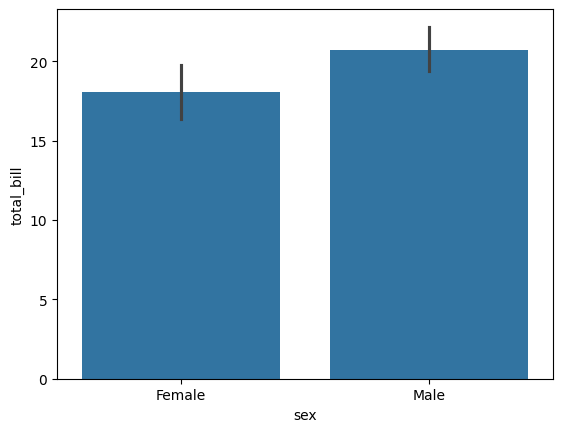

In [27]:
import seaborn as sns

sns.barplot(x='sex', y='total_bill', data=tips_df)

In [28]:
ci_male = sm.stats.weightstats.DescrStatsW(male_bills).tconfint_mean()
ci_female = sm.stats.weightstats.DescrStatsW(female_bills).tconfint_mean()

print(f"CI Male {ci_male}", f"CI Female {ci_female}", sep='\n')

CI Male (np.float64(19.286415891605465), np.float64(22.20173697463659))
CI Female (np.float64(16.349902505118724), np.float64(19.76389059832955))
